<a href="https://colab.research.google.com/github/MuntasirAraf14/EDA_-Exploratory-Data-Analysis-/blob/main/EDA_project(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# US Accidents Exploratory Data **Analysis**
TODO - talk about EDA

TODO - talk about the dataset(source, what it contains, how it will be useful)
*   Kaggle
*   Information about accidents

*   can be useful to prevent accidents







In [1]:
pip install opendatasets --upgrade --quiet


##Download Data


In [2]:
import opendatasets as od

download_url = 'https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents'

od.download(download_url)


Skipping, found downloaded files in "./us-accidents" (use force=True to force download)


In [3]:
data_filename = './us-accidents/US_Accidents_March23.csv'

In [4]:
import os

data_filename = './us-accidents/US_Accidents_March23.csv'
size = os.path.getsize(data_filename)
print(f"File size: {size / (1024**3):.2f} GB")

File size: 2.85 GB


##Data Preparation and Cleaning


*   Load the file using Pandas
*   Look at some information about the data &    the columns

*   Fix any missing or incorrect values



In [5]:
import pandas as pd

In [6]:
import pandas as pd

chunk_size = 200000

for df in pd.read_csv(data_filename, chunksize=chunk_size):
    # Perform EDA on each chunk
    print(df.describe())

            Severity      Start_Lat      Start_Lng  End_Lat  End_Lng  \
count  200000.000000  200000.000000  200000.000000      0.0      0.0   
mean        2.410060      35.402579    -104.355926      NaN      NaN   
std         0.494724       4.582634      17.870632      NaN      NaN   
min         1.000000      25.433098    -123.813927      NaN      NaN   
25%         2.000000      33.754379    -118.437279      NaN      NaN   
50%         2.000000      34.120522    -117.370598      NaN      NaN   
75%         3.000000      38.514824     -83.764334      NaN      NaN   
max         4.000000      44.895218     -70.590034      NaN      NaN   

        Distance(mi)  Temperature(F)  Wind_Chill(F)    Humidity(%)  \
count  200000.000000    197165.00000   21390.000000  196757.000000   
mean        0.033965        65.68728      30.399621      63.903195   
std         0.535451        16.43741      19.850108      21.603255   
min         0.000000       -13.00000     -29.300000       4.000000   
2

In [7]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [8]:
len(df.columns)

46

In [9]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numeric_df = df.select_dtypes(include=numerics)
len(numeric_df.columns)

13

#Percantage of Missing values in one column








In [10]:
missing_percentages = df.isna().sum().sort_values(ascending=False)/len(df)*100
missing_percentages

,0
Precipitation(in),40.305622
Wind_Chill(F),38.464414
Wind_Speed(mph),10.160132
Weather_Condition,2.873966
Visibility(mi),2.787513
Humidity(%),2.440145
Wind_Direction,2.423789
Temperature(F),2.372385
Pressure(in),2.188576
Weather_Timestamp,1.720485


<Axes: >

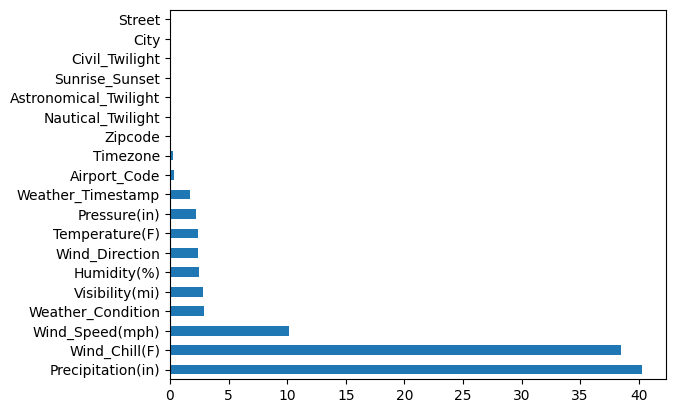

In [11]:
missing_percentages[missing_percentages != 0].plot(kind='barh')

##Exploratory Analysis & Visualization


Columns we'll analyze :


*   City

*   Start Time

*   Start Lat, Start Lng

*   Temperature
*   Weather Condition



##City

In [12]:
df.City

,City
7600000,Charlotte
7600001,Atlanta
7600002,Brooksville
7600003,Hollywood
7600004,Lake City
...,...
7728389,Riverside
7728390,San Diego
7728391,Orange
7728392,Culver City


In [13]:
cities = df.City.unique()
len(cities)

5986

In [14]:
cities_by_accident = df.City.value_counts()
cities_by_accident[:10]

,count
City,
Los Angeles,2501
Houston,2259
Portland,2248
Miami,1947
Chicago,1927
Dallas,1886
Salt Lake City,1836
Atlanta,1714
Charlotte,1530


In [15]:
'New York' in cities

True

<Axes: ylabel='City'>

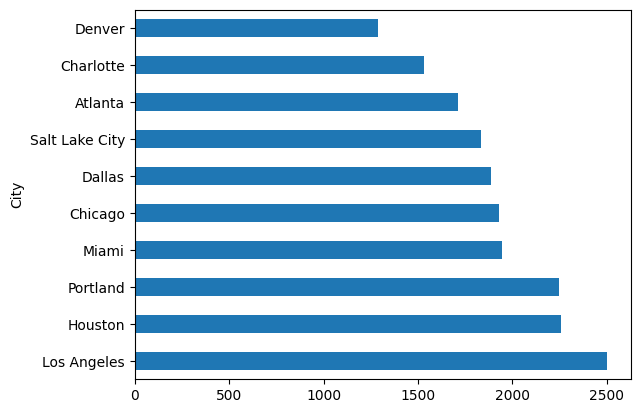

In [16]:
cities_by_accident[:10].plot(kind='barh')

In [17]:
import seaborn as sns

In [18]:
sns.set_style('darkgrid')

/tmp/ipykernel_26654/80215261.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cities_by_accident[:10])


<Axes: xlabel='count', ylabel='Density'>

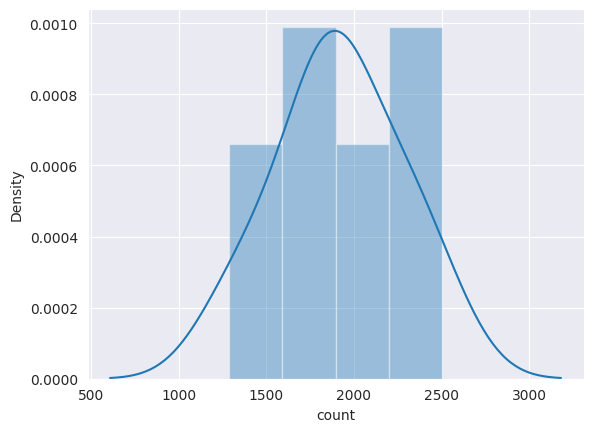

In [19]:
sns.distplot(cities_by_accident[:10])

In [20]:
high_accident_cities = cities_by_accident[cities_by_accident >= 1000]
len(high_accident_cities)


12

In [21]:
low_accident_cities = cities_by_accident[cities_by_accident < 1000]
len(low_accident_cities)

5973

/tmp/ipykernel_26654/2843252471.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(high_accident_cities)


<Axes: xlabel='count', ylabel='Density'>

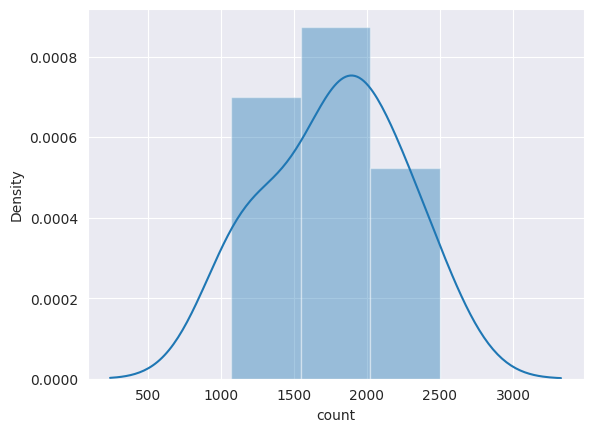

In [22]:
sns.distplot(high_accident_cities)

/tmp/ipykernel_26654/469555131.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(low_accident_cities)


<Axes: xlabel='count', ylabel='Density'>

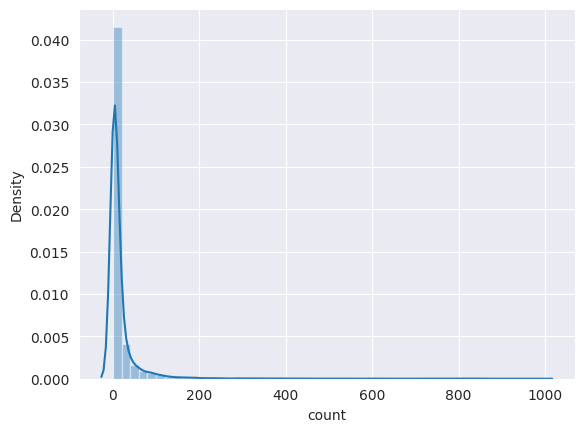

In [23]:
sns.distplot(low_accident_cities)

In [24]:
cities_by_accident[cities_by_accident == 1]

,count
City,
Clarksdale,1
Byrdstown,1
Lacombe,1
Latta,1
Fort Jones,1
...,...
Clifton Springs,1
Galivants Ferry,1
Wakeeney,1


##Start Time

In [25]:
df.Start_Time = pd.to_datetime(df.Start_Time)

In [26]:
df.Start_Time.iloc[0]

Timestamp('2017-12-18 19:52:25')

/tmp/ipykernel_26654/362819596.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Start_Time.dt.hour, bins=24, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

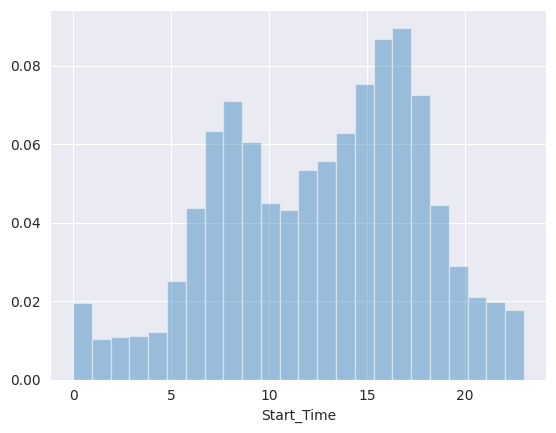

In [27]:
sns.distplot(df.Start_Time.dt.hour, bins=24, kde=False, norm_hist=True)

##Most Accidents occur between 7-9 AM, probably people were hurry for going office

/tmp/ipykernel_26654/308908771.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Start_Time.dt.dayofweek, bins=7, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

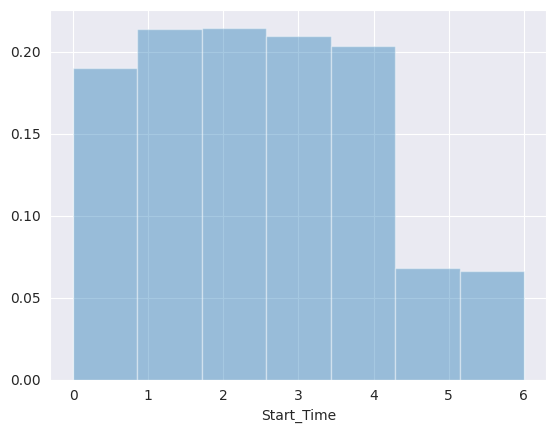

In [28]:
sns.distplot(df.Start_Time.dt.dayofweek, bins=7, kde=False, norm_hist=True)

##Is the distribution of accidents by hour the same on weekends as on weekdays

/tmp/ipykernel_26654/3630331899.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sundays_start_time.dt.hour, bins=24, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

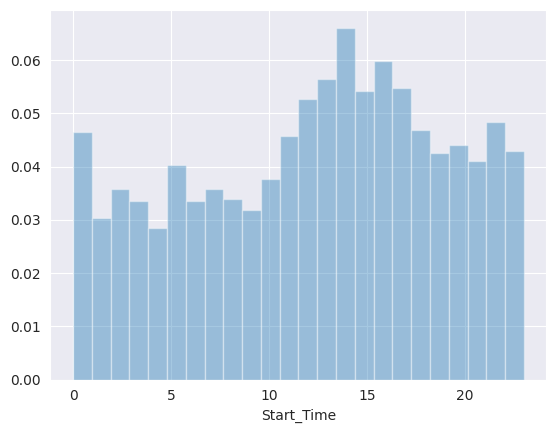

In [29]:
sundays_start_time = df.Start_Time[df.Start_Time.dt.dayofweek == 6]
sns.distplot(sundays_start_time.dt.hour, bins=24, kde=False, norm_hist=True)

##On Sundays, the peak occurs between 12 pm and 2 pm

/tmp/ipykernel_26654/1439261698.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Start_Time.dt.month, bins=12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

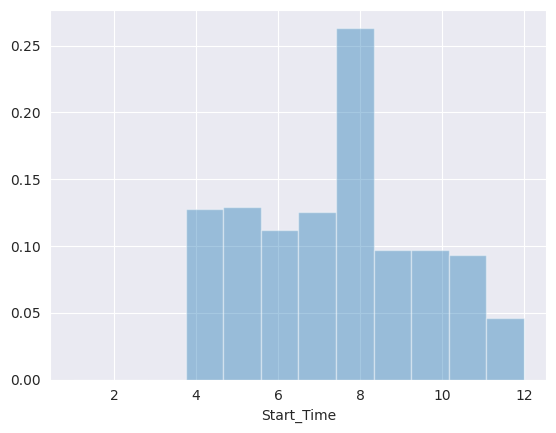

In [30]:
sns.distplot(df.Start_Time.dt.month, bins=12, kde=False, norm_hist=True)

#Start Latitude & Longitude

In [31]:
df.Start_Lat

,Start_Lat
7600000,35.241768
7600001,33.686020
7600002,28.511380
7600003,25.972830
7600004,30.001420
...,...
7728389,34.002480
7728390,32.766960
7728391,33.775450
7728392,33.992460


In [32]:
df.Start_Lng

,Start_Lng
7600000,-80.938688
7600001,-84.307080
7600002,-82.241413
7600003,-80.236330
7600004,-82.600900
...,...
7728389,-117.379360
7728390,-117.148060
7728391,-117.847790
7728392,-118.403020


<Axes: xlabel='Start_Lng', ylabel='Start_Lat'>

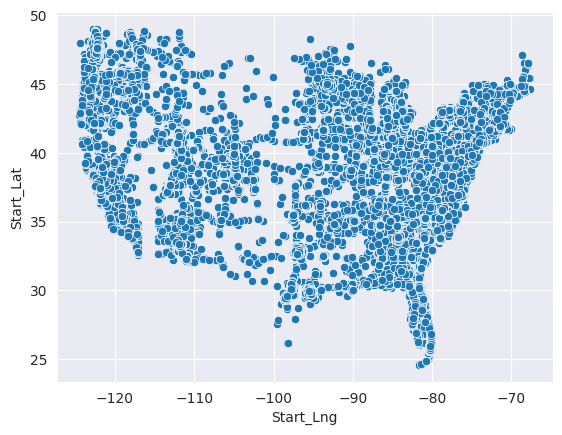

In [33]:
sns.scatterplot(x=df.Start_Lng, y=df.Start_Lat)

In [34]:
import folium

In [35]:
lat, lon = df.Start_Lat.iloc[0], df.Start_Lng.iloc[0]
lat, lon

(np.float64(35.241768), np.float64(-80.938688))

In [36]:
for x in df[['Start_Lat', 'Start_Lng']].sample(100).iterrows():
  print(x[1])

Start_Lat     37.49908
Start_Lng   -121.92698
Name: 7677766, dtype: float64
Start_Lat    32.648854
Start_Lng   -96.776194
Name: 7610822, dtype: float64
Start_Lat     39.88935
Start_Lng   -104.98768
Name: 7606381, dtype: float64
Start_Lat    42.31176
Start_Lng   -83.68776
Name: 7663252, dtype: float64
Start_Lat     47.474271
Start_Lng   -121.897046
Name: 7717468, dtype: float64
Start_Lat    27.91987
Start_Lng   -82.51646
Name: 7602618, dtype: float64
Start_Lat     34.02503
Start_Lng   -117.72796
Name: 7717644, dtype: float64
Start_Lat    39.40739
Start_Lng   -74.55643
Name: 7641489, dtype: float64
Start_Lat     34.155641
Start_Lng   -118.468388
Name: 7665450, dtype: float64
Start_Lat    33.06702
Start_Lng   -97.01665
Name: 7713997, dtype: float64
Start_Lat    38.18975
Start_Lng   -85.73424
Name: 7657170, dtype: float64
Start_Lat    40.85002
Start_Lng   -73.94399
Name: 7606591, dtype: float64
Start_Lat     33.46196
Start_Lng   -112.13976
Name: 7632957, dtype: float64
Start_Lat    32.7390

In [37]:
zip(list(df.Start_Lat.sample(100)), list(df.Start_Lng.sample(100)))

In [38]:
map = folium.Map()
marker = folium.Marker((lat, lon))
marker.add_to(map)
map

In [39]:
from folium.plugins import HeatMap

map = folium.Map()
HeatMap(zip(list(df.Start_Lat), list(df.Start_Lng))).add_to(map)
map

In [40]:
!pip install selenium


In [43]:
# Install Firefox and geckodriver for Folium's _to_png functionality
!apt-get install firefox-esr -y > /dev/null 2>&1
# Update to geckodriver 0.37.0 for compatibility with Firefox 152.*
!wget -q https://github.com/mozilla/geckodriver/releases/download/v0.37.0/geckodriver-v0.37.0-linux64.tar.gz
!tar -xzf geckodriver-v0.37.0-linux64.tar.gz
!chmod +x geckodriver
!mv geckodriver /usr/local/bin

from folium.plugins import HeatMap
import folium
import os

# Limit the number of points for visualization to prevent performance issues
# This also helps in creating a more readable heatmap for dense data
# and avoids potential memory issues or crashes during rendering with a very large dataset.
# A sample size of 10,000 points is a good starting point for large datasets.
heat_data = df[['Start_Lat', 'Start_Lng']].sample(10000).values.tolist()

map = folium.Map()
HeatMap(heat_data).add_to(map)

# Save as PNG instead of just displaying
map.save('heatmap.html')  # optional, keeps interactive version too

# Use a different delay if the map is complex and takes longer to load
# If the error persists, consider increasing the delay or using a lower resolution capture if available.
try:
    img_data = map._to_png(5)  # 5 sec delay so tiles load before capture
    with open('heatmap.png', 'wb') as f:
        f.write(img_data)
    print("Heatmap saved as 'heatmap.png'")
except Exception as e:
    print(f"Error saving heatmap as PNG: {e}")
    print("Please ensure that the necessary browser and WebDriver are correctly installed and configured.")

map

Error saving heatmap as PNG: Message: Process unexpectedly closed with status 255

Please ensure that the necessary browser and WebDriver are correctly installed and configured.


In [44]:
![Accident Heatmap](heatmap.png)

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `[Accident Heatmap](heatmap.png)'


##Ask & Answer Questions



* Are there more accidents in warmer or colder areas?
* Which 5 states have the highest number of accident? How about per capita?

* Does New Yourk show up in the data? If yes, why is the count lower if this is the most populated city?



* Among the top 100 cities in number of accidents, which states do they belong to most frequently.

* What time of the day are accidetns most frequently
* Which days of the week have the most accidents ?
* Which months have the most accidents?

* What is the trend of accidents year over year (decreasing/increasing)?

* when is accidents per unit of traffic the highest?







##Summary and Conclusion


#Insights:

*   The number of accidents per city decreases exponentially
*   Less than 5% of cities have more than yearly 1000 accidents
* Over 1200 cities have reported just one accident (need to investigate)

